In [5]:
from qiskit import QuantumCircuit, Aer, execute
import numpy as np

# Step 1: Create the Bell state |Ψ−> = (|10> − |01>)/sqrt(2)
def create_bell_state():
    qc = QuantumCircuit(2)
    qc.x(1)             # Prepare |10>
    qc.h(0)             # Apply Hadamard to qubit 0
    qc.cx(0, 1)         # Apply CNOT with qubit 0 as control and qubit 1 as target
    return qc

# Step 2: Add measurement bases
def add_measurement_bases(qc, basis_qubit_0, basis_qubit_1):
    """Add measurement bases to the circuit."""
    if basis_qubit_0 == 'X':
        qc.h(0)  # Rotate to X-basis
    elif basis_qubit_0 == 'Y':
        qc.sdg(0)  # Rotate to Y-basis
        qc.h(0)
    
    if basis_qubit_1 == 'X':
        qc.h(1)  # Rotate to X-basis
    elif basis_qubit_1 == 'Y':
        qc.sdg(1)  # Rotate to Y-basis
        qc.h(1)
    
    qc.measure_all()
    return qc

# Step 3: Simulate and collect results
def simulate_circuit(qc, shots=1024):
    simulator = Aer.get_backend('qasm_simulator')
    result = execute(qc, simulator, shots=shots).result()
    return result.get_counts()

# Example: Create the Bell state and measure in the X⊗Z basis
bell_state = create_bell_state()
measurement_circuit = add_measurement_bases(bell_state, 'X', 'Z')
counts = simulate_circuit(measurement_circuit)

# Display the results
print("Measurement Results:", counts)

Measurement Results: {'00': 282, '10': 253, '11': 260, '01': 229}


In [10]:
def process_results(counts, shots=1024):
    """Compute probabilities and expected value."""
    # Map outcomes to x, y values
    mapping = {'00': (1, 1), '01': (1, -1), '10': (-1, 1), '11': (-1, -1)}
    
    # Initialize probabilities and expected value
    probabilities = {}
    expected_value = 0
    
    for outcome, count in counts.items():
        x, y = mapping[outcome]
        p_xy = count / shots
        probabilities[(x, y)] = p_xy
        expected_value += x * y * p_xy  # x * y * p(x, y)
    
    return probabilities, expected_value

# Process the results
probabilities, expected_value = process_results(counts)

# Display results
print("Probabilities (p_ij(x, y)):", probabilities)
print("Expected Value:", expected_value)

Probabilities (p_ij(x, y)): {(1, 1): 0.275390625, (-1, 1): 0.2470703125, (-1, -1): 0.25390625, (1, -1): 0.2236328125}
Expected Value: 0.05859375


In [11]:
# Define the measurement bases
measurement_bases = [
    ('X', 'X'), ('X', 'Y'), ('X', 'Z'), 
    ('Z', 'X'), ('Z', 'Y'), ('Z', 'Z')
]

# Dictionary to store results
results = {}

# Iterate over all measurement bases
for basis_0, basis_1 in measurement_bases:
    # Create the Bell state circuit
    bell_state = create_bell_state()
    
    # Add measurement bases
    circuit = add_measurement_bases(bell_state, basis_0, basis_1)
    
    # Simulate the circuit
    counts = simulate_circuit(circuit)
    
    # Process results
    probabilities, expected_value = process_results(counts)
    
    # Store results
    results[(basis_0, basis_1)] = {
        "counts": counts,
        "probabilities": probabilities,
        "expected_value": expected_value
    }

# Display the expected values for all bases
for basis, data in results.items():
    print(f"Measurement Basis {basis}: Expected Value = {data['expected_value']}")

Measurement Basis ('X', 'X'): Expected Value = 1.0
Measurement Basis ('X', 'Y'): Expected Value = -0.0234375
Measurement Basis ('X', 'Z'): Expected Value = -0.033203125
Measurement Basis ('Z', 'X'): Expected Value = 0.00390625
Measurement Basis ('Z', 'Y'): Expected Value = -0.046875
Measurement Basis ('Z', 'Z'): Expected Value = -1.0


In [12]:
# Example: Assign expected values to the terms in S
# Replace with the actual bases you used
E_AB = results[('X', 'X')]['expected_value']
E_AB_prime = results[('X', 'Y')]['expected_value']
E_A_prime_B = results[('Z', 'X')]['expected_value']
E_A_prime_B_prime = results[('Z', 'Y')]['expected_value']

# Compute S
S = E_AB + E_AB_prime + E_A_prime_B - E_A_prime_B_prime
print(f"CHSH parameter S = {S}")

CHSH parameter S = 1.02734375


In [13]:
import statistics

# Function to compute S for one experiment
def compute_chsh_s():
    # Repeat measurements for all required bases
    measurement_bases = [
        ('X', 'X'), ('X', 'Y'), ('Z', 'X'), ('Z', 'Y')
    ]
    results = {}
    
    for basis_0, basis_1 in measurement_bases:
        # Create the Bell state circuit
        bell_state = create_bell_state()
        
        # Add measurement bases
        circuit = add_measurement_bases(bell_state, basis_0, basis_1)
        
        # Simulate the circuit
        counts = simulate_circuit(circuit)
        
        # Process results
        _, expected_value = process_results(counts)
        
        # Store expected values
        results[(basis_0, basis_1)] = expected_value
    
    # Compute S using the CHSH formula
    E_AB = results[('X', 'X')]
    E_AB_prime = results[('X', 'Y')]
    E_A_prime_B = results[('Z', 'X')]
    E_A_prime_B_prime = results[('Z', 'Y')]
    
    S = E_AB + E_AB_prime + E_A_prime_B - E_A_prime_B_prime
    return S

# Repeat the experiment multiple times
num_experiments = 5
S_values = [compute_chsh_s() for _ in range(num_experiments)]

# Compute mean and standard deviation of S
mean_S = statistics.mean(S_values)
std_S = statistics.stdev(S_values)

# Display results
print(f"CHSH parameter S values: {S_values}")
print(f"Mean S: {mean_S}")
print(f"Standard Deviation of S: {std_S}")

CHSH parameter S values: [0.974609375, 0.9375, 1.0546875, 1.046875, 1.068359375]
Mean S: 1.01640625
Standard Deviation of S: 0.0571535236757515


In [14]:
from qiskit import QuantumCircuit

# Example: Create a Bell state circuit
circuit = QuantumCircuit(2)
circuit.h(0)  # Apply Hadamard to qubit 0
circuit.cx(0, 1)  # Apply CNOT with qubit 0 as control and qubit 1 as target

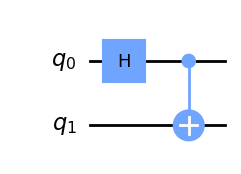

In [15]:
# Matplotlib visualization (prettier, requires matplotlib)
circuit.draw(output='mpl')